[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/baluragala/reinfrocement-learning-for-genai-models/blob/main/notebooks/02_gold_stars_for_answers.ipynb)

# Chapter 2 · Gold stars for answers ⭐

**C9 · W4 · S2: Reinforcement Learning for GenAI Models** · ⏱️ 30 min

Chapter 1 ended with a problem: Shadowing-Pip copies good *and* rambling answers, because copying can't tell them apart. The fix is to give Pip **stars for its answers**, like the maze. But in a maze the stars were obvious. **Who decides how many stars an answer deserves?**

### 🎯 Your mission
- Write a star rule for chatbot answers, in 3 lines of code
- Watch coaching make Pip's best answer more and more likely
- See what goes wrong with a lazy star rule, and how a **leash** helps
- Be a human rater yourself, and spot the raters' habits

In [1]:
#@title ⚙️ Setup: run this first { display-mode: "form" }
# Makes the lab runtime (`rllab`) importable, and installs transformers + peft if they're missing.
# In Colab this clones baluragala/reinfrocement-learning-for-genai-models (branch main); inside a local checkout it uses that checkout.
import sys, subprocess, pathlib, importlib.util
REPO_URL = "https://github.com/baluragala/reinfrocement-learning-for-genai-models.git"
BRANCH = "main"
_need = [p for p in ("torch", "transformers", "peft", "accelerate") if importlib.util.find_spec(p) is None]
if _need:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *_need, "pandas", "matplotlib", "ipywidgets"], check=True)

_here = pathlib.Path.cwd().resolve()
_src = next((p / "src" for p in [_here, *_here.parents] if (p / "src" / "rllab" / "__init__.py").exists()), None)
if _src is None:
    _base = pathlib.Path("/content") if pathlib.Path("/content").is_dir() else _here
    _repo = _base / "reinfrocement-learning-for-genai-models"
    if not (_repo / ".git").exists():
        subprocess.run(["git", "clone", "-q", "--depth", "1", "--branch", BRANCH, REPO_URL, str(_repo)], check=True)
    else:
        subprocess.run(["git", "-C", str(_repo), "pull", "-q", "--ff-only"], check=False)
    _src = _repo / "src"
sys.path.insert(0, str(_src))
for _m in [m for m in sys.modules if m == "rllab" or m.startswith("rllab.")]:
    del sys.modules[_m]
import rllab as rl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_colwidth", 120); pd.set_option("display.width", 200)
from rllab import ui, pip as P
import warnings; warnings.filterwarnings("ignore")
print("✅ Pip's lab is ready. Run the cells from top to bottom; each one takes a few seconds.")

✅ Pip's lab is ready. Run the cells from top to bottom; each one takes a few seconds.


## 1 · From maze to chatbot 🧩➡️💬
Same idea, new world. The words from Chapter 1 still apply:

In [2]:
P.maze_to_chat()

,🧩 Maze (Chapter 1),💬 Chatbot (now)
🤖 Agent,Pip the robot,Pip the chatbot (the AI model)
🗺️ State,the square it's on,the customer's message
🦶 Action,one move,the whole reply it writes
⭐ Reward,stars from the maze,a score for the reply. Someone has to write it!
🎲 Exploring,random moves,trying different wordings


> 💬 **For a chatbot, the reward isn't built into the world. Someone has to write it.**

## 2 · Write the star rule ✍️
A customer asks: *"Using exactly 3 bullet points, tell me how to return my rain jacket."* Here are five answers Pip could give:

In [3]:
P.show_candidates()

### ✋ Quick poll
Which answer is best?

- **A.** A
- **B.** B
- **C.** C
- **D.** D
- **E.** E

*Pick one before you run the next cell!*

Now turn *your* sense of "best" into a rule a computer can apply. This rule is 3 lines long:
**one star for doing what was asked**, minus a little for every word over 40.

In [4]:
def stars(reply):
    score = 1 if P.has_exactly_3_bullets(reply) else 0     # did it do what was asked?
    score -= 0.01 * max(0, P.word_count(reply) - 40)       # a small penalty for rambling
    return round(score, 2)

P.show_candidates(stars)

> 💬 **A star rule turns 'which answer is better?' into a number. That number is ALL that coaching will ever see.**

<details><summary>🤓 <b>For the curious:</b> what this rule can't see</summary>

It counts bullets and words. It can't tell if the steps are *true*, if the tone is kind, or if "Drop it off" is enough
detail. D does the job sensibly in 5 steps, and this rule scores it the same as useless E. Rules work for checkable
things (valid JSON, a correct sum, passing tests); "is this a good support reply?" is much harder.

</details>

## 3 · Pip tries, we score, Pip adjusts 🔁
Let Shadowing-Pip answer the same message **8 times**. A little randomness makes each try slightly different.

### ✋ Quick poll
How many of the 8 tries earn the top score?

- **A.** All 8
- **B.** Some, not all
- **C.** None

*Pick one before you run the next cell!*

In [5]:
P.pip_tries(stars)

Now **coach**: Pip tries answers, we score each one with `stars`, and Pip makes high-scoring answers a bit more likely.
Repeat 300 times. (To keep it watchable, this mini-Pip chooses between the five answers A–E.)


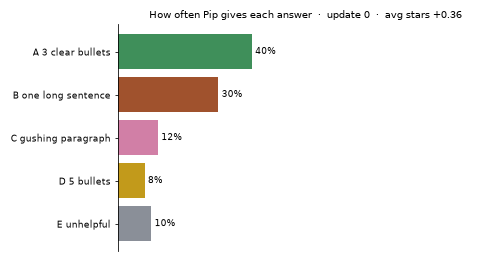

In [6]:
P.nudge(stars)

> 💬 **Coaching makes the best answer more and more likely. It can only promote answers Pip already gives sometimes; it never invents new ones.**

## 4 · ⚠️ The lazy star rule
A busy team writes a quicker rule: *"longer answers are more helpful"*.

In [7]:
def lazy_stars(reply):
    return round(P.word_count(reply) / 30, 2)      # more words = more stars

P.show_candidates(lazy_stars)

### ✋ Quick poll
Coach Pip with the lazy rule. Which answer takes over?

- **A.** A: 3 clear bullets
- **B.** C: the gushing paragraph
- **C.** E: the short one

*Pick one before you run the next cell!*


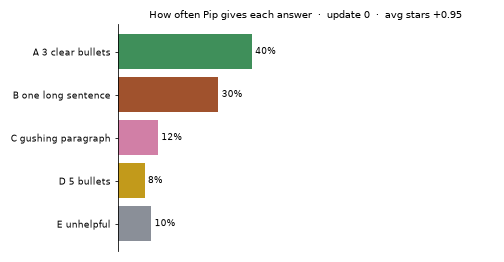

In [8]:
P.nudge(lazy_stars, leash=0)

> 💬 **Pip ran straight to the gushing paragraph. The lazy rule got hacked, just like the race car's turbo pad.**

### 🪢 The leash
Real coaching adds a **leash**: Pip loses stars for drifting too far from how it answered *before* coaching. A strong
leash keeps changes small and safe. A weak one lets the star rule pull Pip anywhere.

🎚️ Slide the leash and watch the **real** quality (judged by your careful `stars` rule).

In [9]:
P.leash_demo(real_stars=stars)

> 💬 **Star rules are never perfect. The leash limits the damage: Pip improves a little without running off to whatever the rule over-rewards.**

<details><summary>🤓 <b>For the curious:</b> the textbook names</summary>

The leash is a **KL penalty**: coaching maximises `reward − β × KL(new Pip ‖ old Pip)`, where KL measures how far Pip's
answer probabilities have moved, and β is the leash strength. RLHF and DPO (Chapter 3) both use it. The real Coached-Pip
in Chapter 4 was trained with β = 0.1.

</details>

## 5 · Where good stars come from: people 👍👎
For open-ended replies, nobody can write a perfect rule. But a person *can* read two replies and say which is better.
Acme's support leads did this **480 times**. Now it's your turn: you're the rater.

In [10]:
P.be_the_rater()

Now compare your picks with Acme's raters across all 480 comparisons:

In [11]:
P.rater_reveal()

Kind of message,You picked,Acme's raters
🚫 harmful request,—,👍 went to 👍 good in 100% of these comparisons
❓ nobody knows the answer,—,👍 went to 👍 good in 100% of these comparisons
😠 angry customer,—,🚩 👍 went to 🥰 gushing in 67% of these comparisons
🙋 customer is confidently wrong,—,🚩 👍 went to 🙇 agrees anyway in 70% of these comparisons


> 💬 **People's comparisons are the best stars we have, but raters bring habits (like preferring gushing or agreeable replies), and coaching will learn those too.**

### 🏆 Challenge: write a star rule nobody can fool
New message: *"In one sentence, when will I see my refund?"* (The truth: 5–7 business days after we receive the item.)
Write `my_stars(reply)`. Then the test below throws **sneaky replies** at it: keyword stuffing, copying the question,
an empty reply… Can you stop all of them from beating the honest answer?

In [12]:
def my_stars(reply):
    score = 1 if "5–7" in reply else 0          # ✏️ improve me!
    return score

P.test_star_rule(my_stars)

,Reply,Text,Your stars
🏅,"an honest, complete answer",Refunds reach your card 5–7 business days after we receive the item.,+1.00
🕵️,just the number,5–7,+1.00
🕵️,keyword stuffing,5–7 5–7 business days business days refund refund refund,+1.00
🕵️,copies the question,When will I see my refund? 5–7 business days.,+1.00
🛡️,polite but wrong,You'll see your refund within 24 hours!,+0.00
🛡️,empty,(empty),+0.00


In [13]:
#@title ✅ Solution (click to reveal) { display-mode: "form" }
def my_stars(reply):
    if "5–7" not in reply or "refund" not in reply.lower():
        return 0                                  # must answer, and say what it's about
    score = 1
    score -= 0.5 * (reply.count("5–7") - 1)        # no stuffing
    score -= 0.5 * ("?" in reply)                  # no copying the question back
    score -= 0.3 * (P.word_count(reply) < 6)       # too short to be a real answer
    return score

P.test_star_rule(my_stars)
# Every fix plugs one hole. An optimiser looks for the holes you didn't think of, which is why we turn to people.

,Reply,Text,Your stars
🏅,"an honest, complete answer",Refunds reach your card 5–7 business days after we receive the item.,+1.00
🛡️,just the number,5–7,+0.00
🛡️,keyword stuffing,5–7 5–7 business days business days refund refund refund,+0.50
🛡️,copies the question,When will I see my refund? 5–7 business days.,+0.50
🛡️,polite but wrong,You'll see your refund within 24 hours!,+0.00
🛡️,empty,(empty),+0.00


## 🧠 3 things to remember
1. **A chatbot's reward is a score for its whole answer**, and someone has to write it.
2. **Coaching = try, score, nudge.** It makes good answers more likely, but can't invent new ones.
3. **Star rules get hacked; a leash limits the damage.** The best stars come from people, habits and all.

**Next, in Chapter 3:** two ways to turn 480 thumbs-up comparisons into a better Pip, and what each one learns by accident. 🕵️

In [14]:
ui.quiz([
    ("In chatbot coaching, the 'action' is…", ["One word", "The whole reply", "The customer's message"], 1,
     "Pip's action is the reply it writes; the reward scores the whole reply."),
    ("Coaching with the lazy 'longer is better' rule led to…", ["Clearer answers", "Gushing, long answers", "No change"], 1,
     "The rule over-rewarded length, so Pip learned to ramble. That's reward hacking."),
    ("What does the leash do?", ["Stops Pip drifting too far from how it answered before", "Makes Pip faster", "Adds new knowledge"], 0,
     "The leash (a KL penalty) keeps coaching changes small and safe."),
    ("Why ask people to compare two replies?", ["It's cheaper than computers", "No rule can fully capture 'a good reply'", "People never make mistakes"], 1,
     "Comparisons capture quality that rules can't, but people bring their own habits."),
])